<h1 style="color:pink;">
Hemoglobin Disorder Classification Using Machine Learning and Neural Networks 🩸🔎
</h1ٍ>



<h3 style="color:#89CFF0;">
- Task 1.1
</h5>

<h3 style="color:PINK;">
 > Load and Explore
</h5>ٍ



<h3 style="color:#89CFF0;">
 > 1️⃣ Import Libraries
</h5>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

<h3 style="color:#89CFF0;">
 > 2️⃣ Load Dataset
</h5>

In [2]:
df = pd.read_csv("/content/hbvar_synthetic_clinical_dataset.csv")

<h3 style="color:#89CFF0;">
     3️⃣ Display First Rows <br>
     4️⃣ Check Shape  <br>
     5️⃣ Check Data Types <br>
     6️⃣ Check Missing Values
</h3>

In [ ]:
df.head()
print("Rows and Columns:", df.shape)
df.info()
df.isnull().sum()


Rows and Columns: (3000, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   variant_type      3000 non-null   object 
 1   ethnicity         3000 non-null   object 
 2   anemia            3000 non-null   int64  
 3   jaundice          3000 non-null   int64  
 4   splenomegaly      3000 non-null   int64  
 5   macrocytosis      3000 non-null   int64  
 6   microcytosis      3000 non-null   int64  
 7   hypochromia       3000 non-null   int64  
 8   poikilocytosis    3000 non-null   int64  
 9   hdeg_chronic      3000 non-null   int64  
 10  hdeg_mild         3000 non-null   int64  
 11  hdeg_moderate     3000 non-null   int64  
 12  hdeg_severe       3000 non-null   int64  
 13  hdeg_hemolytic    3000 non-null   int64  
 14  hdeg_congenital   3000 non-null   int64  
 15  hemoglobin        3000 non-null   float64
 16  rbc_count    

,0
variant_type,0
ethnicity,0
anemia,0
jaundice,0
splenomegaly,0
macrocytosis,0
microcytosis,0
hypochromia,0
poikilocytosis,0
hdeg_chronic,0


<h3 style="color:#89CFF0;">
 > Check Class Balance🔦
</h5>

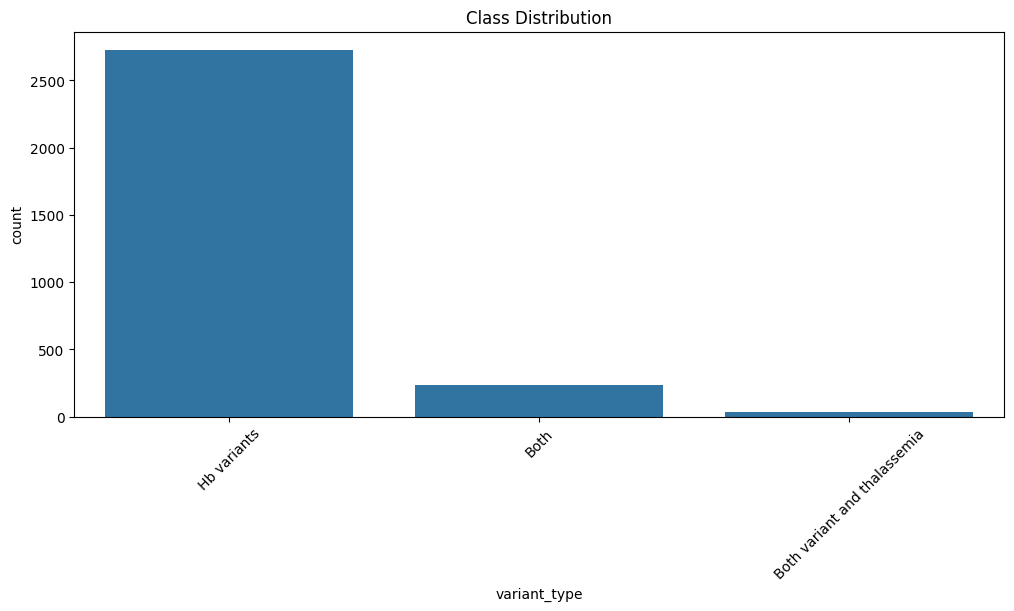

In [ ]:
df["variant_type"].value_counts()

plt.figure(figsize=(12,5))
sns.countplot(x=df["variant_type"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()



The dataset is imbalanced because one class contains significantly more samples than the others.


Therefore, F1-score will be considered an important evaluation metric in this project.

<h3 style="color:PINK;">
 > Task 1.2
</h5>

 <h3 style="color:#89CFF0;">
 >  Features and Target
</h5>

In [ ]:
X = df.drop("variant_type", axis=1)
y = df["variant_type"]

The dataset was separated into features (`X`) and target (`y`).

 <h3 style="color:#89CFF0;">
 >   Encoding Categorical Features
</h5>

In [ ]:
X = pd.get_dummies(X, drop_first=True)

Categorical features were converted into numerical values using one-hot encoding.

 <h3 style="color:#89CFF0;">
 >   Encoding Target Labels
</h5>

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

The target variable was converted into numerical labels using LabelEncoder.

 <h3 style="color:#89CFF0;">
 > Train-Test Split
</h5>

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

The dataset was split into 80% training data and 20% testing data.

 <h3 style="color:#89CFF0;">
 >Data Shapes
</h5>

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 118)
X_test shape: (600, 118)
y_train shape: (2400,)
y_test shape: (600,)


The shapes of the training and testing datasets were checked successfully.

 <h3 style="color:#89CFF0;">
 >Feature Scaling
</h5>

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied using StandardScaler to normalize the data before training the models.

<h3 style="color:PINK;">
 > Task 1.3
    " Logistic Regression "
</h3>

<h3 style="color:#89CFF0;">
Train the Model
</h3>

In [ ]:

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

<h3 style="color:#89CFF0;">
Make Predictions
</h3>

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)

The trained Logistic Regression model was used to predict the test data.

<h3 style="color:#89CFF0;">
Model Evaluation
</h3>

In [ ]:
log_accuracy = accuracy_score(y_test, y_pred_log)

log_precision = precision_score(y_test, y_pred_log, average="weighted")

log_recall = recall_score(y_test, y_pred_log, average="weighted")

log_f1 = f1_score(y_test, y_pred_log, average="weighted")

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)

Accuracy: 0.9366666666666666
Precision: 0.931680148297944
Recall: 0.9366666666666666
F1-score: 0.9340437158469946


The Logistic Regression model was evaluated using accuracy, precision, recall, and F1-score.

<h3 style="color:#89CFF0;">
Confusion Matrix
</h3>

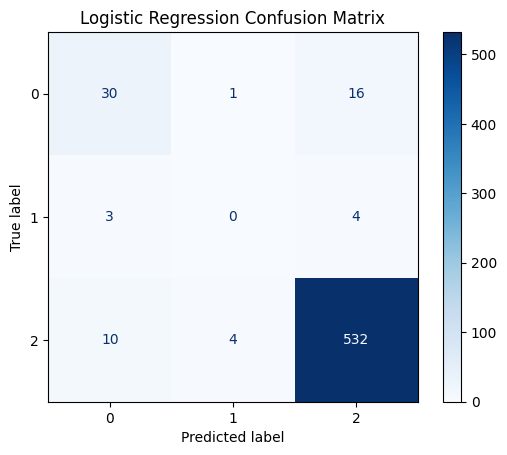

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### Logistic Regression Results

Logistic Regression achieved strong performance with high accuracy and F1-score.

However, the confusion matrix shows that the model performed better on the majority class than on the minority classes due to class imbalance.



<h3 style="color:PINK;">
 > Task 1.3
    " Random Forest "
</h3>

<h3 style="color:#89CFF0;">
Train the Model
</h3>
"

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

<h3 style="color:#89CFF0;">
Make Predictions
</h3>

In [ ]:
y_pred_rf = rf_model.predict(X_test)

<h3 style="color:#89CFF0;">
Model Evaluation
</h3>

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf, average="weighted")

rf_recall = recall_score(y_test, y_pred_rf, average="weighted")

rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

Accuracy: 0.9533333333333334
Precision: 0.9432363636363638
Recall: 0.9533333333333334
F1-score: 0.9482173225976371


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<h3 style="color:#89CFF0;">
Confusion Matrix
</h3>

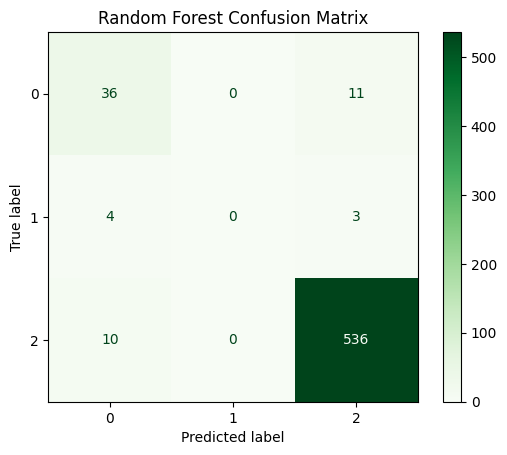

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

### Random Forest Results

Random Forest achieved better performance than Logistic Regression in terms of accuracy and F1-score.

The model performed very well on the majority class, but the minority classes remained more difficult to classify because of class imbalance.

<h3 style="color:PINK;">
 > Task 1.3
    "K-Nearest Neighbors (KNN) "
</h3>

<h3 style="color:#89CFF0;">
Train the Model
</h3>

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

<h3 style="color:#89CFF0;">
Make Predictions
</h3>


In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)

<h3 style="color:#89CFF0;">
Model Evaluation
</h3>


In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(y_test, y_pred_knn, average="weighted")

knn_recall = recall_score(y_test, y_pred_knn, average="weighted")

knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

Accuracy: 0.9366666666666666
Precision: 0.9204405797101448
Recall: 0.9366666666666666
F1-score: 0.9234828360921135


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<h3 style="color:#89CFF0;">
Confusion Matrix
</h3>

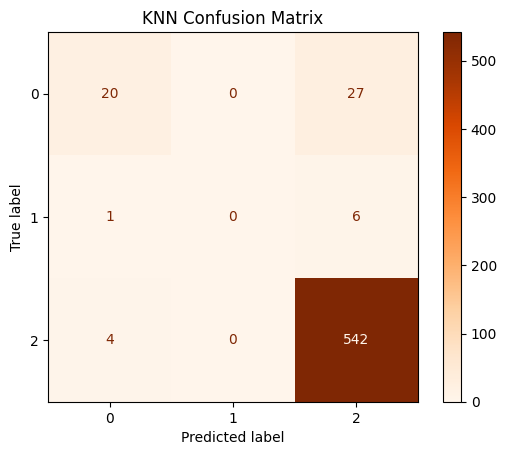

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)

disp.plot(cmap="Oranges")

plt.title("KNN Confusion Matrix")

plt.show()

### KNN Results

KNN achieved good performance, but its accuracy and F1-score were lower than Random Forest.

The confusion matrix shows that the model struggled more with minority classes due to class imbalance.

<h3 style="color:PINK;">
 > Summary Table
    "Model Comparison "
</h3>

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","KNN"],

    "Accuracy": [log_accuracy,rf_accuracy,knn_accuracy],
    "Precision": [log_precision,rf_precision,knn_precision],
    "Recall": [log_recall,rf_recall,knn_recall],
    "F1-Score": [log_f1,rf_f1,knn_f1]})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.936667,0.931680,0.936667,0.934044
1,Random Forest,0.953333,0.943236,0.953333,0.948217
2,KNN,0.936667,0.920441,0.936667,0.923483


### Best Model Selection

Random Forest achieved the best overall performance among all models.

It produced the highest accuracy and F1-score, making it the most effective model for classifying hemoglobin disorder types in this dataset.🚀

<h3 style="color:PINK;">
 > Step 1 complated 🎉
</h3>

<h3 style="color:PINK;">
🚀 Step 2 — Neural Network
</h3>

<h3 style="color:#89CFF0;">
Build the Neural Network
</h3>

In [ ]:
nn_model = keras.Sequential([

    layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),

    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


A neural network model was created using Dense and Dropout layers.

<h3 style="color:#89CFF0;">
Compile the Model
</h3>

In [ ]:
nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

The model was compiled using the Adam optimizer and categorical loss function.

<h3 style="color:#89CFF0;">
Train the Mode
</h3>

In [ ]:
history = nn_model.fit(
    X_train_scaled,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32
)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8880 - loss: 0.4590 - val_accuracy: 0.9479 - val_loss: 0.1829
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9380 - loss: 0.2178 - val_accuracy: 0.9479 - val_loss: 0.1604
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9417 - loss: 0.1896 - val_accuracy: 0.9500 - val_loss: 0.1600
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9479 - loss: 0.1443 - val_accuracy: 0.9458 - val_loss: 0.1613
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9526 - loss: 0.1369 - val_accuracy: 0.9458 - val_loss: 0.1574
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9526 - loss: 0.1194 - val_accuracy: 0.9417 - val_loss: 0.1681
Epoch 7/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9589 - loss: 0.1164 - val_accuracy: 0.9438 - val_loss: 0.1689
Epoch 8/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9615 - loss: 0.1095 - val_accuracy: 0.9458 - val_loss:

The neural network was trained using the training dataset and validation split.

<h3 style="color:#89CFF0;">
Training and Validation Curves
</h3>

The training and validation accuracy/loss curves were plotted to check model performance and overfitting.

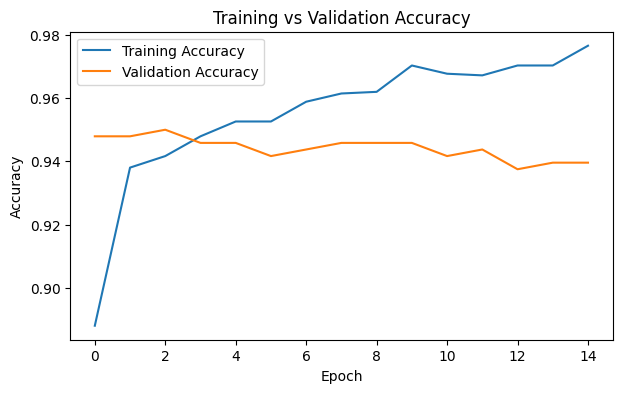

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### Accuracy Curve Analysis

The model achieved high accuracy with slight overfitting in later epochs.

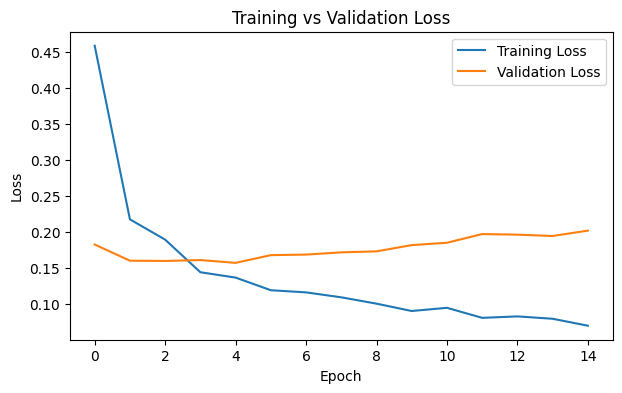

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### Loss Curve Analysis

The loss decreased during training with slight overfitting in later epochs.

<h3 style="color:PINK;">
Evaluate the Neural Network
</h3>

The neural network model was evaluated using the same metrics from Step 1.

<h3 style="color:#89CFF0;">
Evaluate on Test Set
</h3>

In [ ]:
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test)

print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9433 - loss: 0.2949  
Test Accuracy: 0.9433333277702332


<h3 style="color:#89CFF0;">
Predictions
</h3>

In [ ]:
y_pred_nn = nn_model.predict(X_test_scaled)

y_pred_nn = y_pred_nn.argmax(axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


<h3 style="color:#89CFF0;">
Metrics
</h3>

### Add Neural Network to Summary Table

In [ ]:
nn_precision = precision_score(y_test, y_pred_nn, average="weighted")

nn_recall = recall_score(y_test, y_pred_nn, average="weighted")

nn_f1 = f1_score(y_test, y_pred_nn, average="weighted")

print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1-score:", nn_f1)

Precision: 0.9388031045751634
Recall: 0.9433333333333334
F1-score: 0.9407957125987828


<h3 style="color:#89CFF0;">
Add to Summary Table
</h3>

In [ ]:
results.loc[len(results)] = [
    "Neural Network",
    test_accuracy,
    nn_precision,
    nn_recall,
    nn_f1
]

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.936667,0.931680,0.936667,0.934044
1,Random Forest,0.953333,0.943236,0.953333,0.948217
2,KNN,0.936667,0.920441,0.936667,0.923483
3,Neural Network,0.943333,0.938803,0.943333,0.940796


### Final Comparison

Random Forest achieved the best overall performance among all models.

Although the Neural Network achieved strong results, Random Forest produced higher accuracy and F1-score on this dataset.

In [ ]:
!pip install gradio -q

import gradio as gr
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

data_path = "/content/hbvar_synthetic_clinical_dataset.csv"
df = pd.read_csv(data_path)
target = "variant_type"
doctor_features = ["hemoglobin", "hb_f", "mcv", "hb_a2", "hb_s"]
user_features = ["anemia", "jaundice", "splenomegaly"]

y = df[target]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Doctor model
X_doctor = df[doctor_features]

doctor_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())]), doctor_features)])

doctor_model = Pipeline([("preprocessor", doctor_preprocessor),("classifier", RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced"))])
doctor_model.fit(X_doctor, y_encoded)

# General user model
X_user = df[user_features]

user_model = Pipeline([
    ("classifier", RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced"))])
user_model.fit(X_user, y_encoded)

def explain_disorder(prediction):
    prediction = str(prediction).lower()

    explanations = {
        "alpha": "This pattern is related to alpha hemoglobin disorder.",
        "beta": "This pattern is related to beta hemoglobin disorder.",
        "both": "This pattern shows features related to both alpha and beta hemoglobin disorders.",
        "other": "This pattern may belong to another hemoglobin variant."}
    return explanations.get(prediction, "This is the hemoglobin disorder type predicted by the model.")

def doctor_predict(hemoglobin, hb_f, mcv, hb_a2, hb_s):
    input_df = pd.DataFrame(
        [[hemoglobin, hb_f, mcv, hb_a2, hb_s]],
        columns=doctor_features)

    pred = doctor_model.predict(input_df)[0]
    prediction = label_encoder.inverse_transform([pred])[0]
    confidence = doctor_model.predict_proba(input_df).max() * 100
    explanation = explain_disorder(prediction)

    return f"""🩺 Clinical Prediction Result

Predicted Disorder Type:
{prediction}

Meaning:
{explanation}

Confidence Score:
{confidence:.2f}%

Note:
This result is for educational purposes only and does not replace medical diagnosis.
"""

def user_predict(anemia, jaundice, splenomegaly):
    anemia = 1 if anemia == "Yes" else 0
    jaundice = 1 if jaundice == "Yes" else 0
    splenomegaly = 1 if splenomegaly == "Yes" else 0

    input_df = pd.DataFrame(
        [[anemia, jaundice, splenomegaly]],
        columns=user_features)

    pred = user_model.predict(input_df)[0]
    prediction = label_encoder.inverse_transform([pred])[0]
    confidence = user_model.predict_proba(input_df).max() * 100
    explanation = explain_disorder(prediction)

    return f"""🩸 Symptom-Based Prediction

Predicted Disorder Type:
{prediction}

Meaning:
{explanation}

Confidence Score:
{confidence:.2f}%

Note:
This is only a simple symptom-based screening. Laboratory tests are needed for confirmation.
"""

def show_interface(user_type):
    if user_type == "General User":
        return gr.update(visible=True), gr.update(visible=False)
    elif user_type == "Doctor / Laboratory":
        return gr.update(visible=False), gr.update(visible=True)
    return gr.update(visible=False), gr.update(visible=False)

css = """
.gradio-container {
    background: #FFFFFF !important;
    font-family: Arial, sans-serif !important;}

body, p, span, label, div, h1, h2, h3, h4, textarea {
    color: #8B1E3F !important;}

#title {
    background: #8B1E3F;
    padding: 42px;
    border-radius: 24px;
    text-align: center;
    margin-bottom: 25px;}

#title h1,
#title p {
    color: white !important;}

#card,
#user-section,
#doctor-section {
    background: white !important;
    padding: 28px;
    border-radius: 22px;
    border: 2px solid #8B1E3F;
    margin-bottom: 24px;}

#card h3,
#user-section h3,
#doctor-section h3 {
    color: #8B1E3F !important;
    font-size: 30px;}

#card p,
#user-section p,
#doctor-section p {
    color: #8B1E3F !important;
    font-size: 17px;}

label:has(input[type="radio"]) {
    background: white !important;
    border: 2px solid #8B1E3F !important;
    border-radius: 14px !important;
    padding: 12px 18px !important;
    color: #8B1E3F !important;
    font-weight: bold !important;}

label:has(input[type="radio"]:checked) {
    background: #8B1E3F !important;}

label:has(input[type="radio"]:checked) span {
    color: white !important;}

label span {
    color: #8B1E3F !important;}

input,
textarea {
    background: white !important;
    color: #8B1E3F !important;
    border: 2px solid #8B1E3F !important;
    border-radius: 14px !important;}

button {
    background: #8B1E3F !important;
    color: white !important;
    border: none !important;
    border-radius: 14px !important;
    height: 54px !important;
    font-size: 18px !important;
    font-weight: bold !important;}

button:hover {
    background: #6E1831 !important;}
"""

with gr.Blocks(css=css, title="Hemoglobin Disorder Classification") as demo:

    gr.HTML("""
    <div id="title">
        <h1>🩸 Hemoglobin Disorder Classification</h1>
        <p>AI System for Predicting Hemoglobin Disorder Types</p>
    </div>
    """)

    gr.HTML("""
    <div id="card">
        <h3>Project Description</h3>
        <p>
        This project uses machine learning to predict hemoglobin disorder types.
        It supports both general users and healthcare professionals.
        </p>
        <p><b style="color:#8B1E3F;">Developed by:</b> Aldanah Saleh</p>
    </div>
    """)

    user_type = gr.Radio(
        choices=["General User", "Doctor / Laboratory"],
        label="Choose User Type")

    with gr.Group(visible=False, elem_id="user-section") as user_section:
        gr.HTML("""
        <h3>👤 General User</h3>
        <p>Answer these questions based on your symptoms.</p>""")

        anemia_input = gr.Radio(
            choices=["Yes", "No"],
            label="Do you often feel tired or dizzy?")

        jaundice_input = gr.Radio(
            choices=["Yes", "No"],
            label="Have you noticed yellowing in your eyes or skin?")

        spleen_input = gr.Radio(
            choices=["Yes", "No"],
            label="Do you feel pain or swelling in the upper left abdomen?")

        user_button = gr.Button("Predict From Symptoms")

        user_output = gr.Textbox(
            label="Prediction Result",
            lines=8)

        user_button.click(
            fn=user_predict,
            inputs=[anemia_input, jaundice_input, spleen_input],
            outputs=user_output)

    with gr.Group(visible=False, elem_id="doctor-section") as doctor_section:
        gr.HTML("""
        <h3>🩺 Doctor / Laboratory</h3>
        <p>Enter laboratory values.</p>""")

        hemoglobin_input = gr.Number(
            label="Hemoglobin (Hb)",
            value=float(df["hemoglobin"].median()))

        hb_f_input = gr.Number(
            label="Hb F",
            value=float(df["hb_f"].median()))

        mcv_input = gr.Number(
            label="MCV",
            value=float(df["mcv"].median()))

        hb_a2_input = gr.Number(
            label="Hb A2",
            value=float(df["hb_a2"].median()))

        hb_s_input = gr.Number(
            label="Hb S",
            value=float(df["hb_s"].median()))

        doctor_button = gr.Button("Predict From Laboratory Data")

        doctor_output = gr.Textbox(
            label="Prediction Result",lines=9)

        doctor_button.click(
            fn=doctor_predict,
            inputs=[hemoglobin_input,hb_f_input,mcv_input,hb_a2_input,hb_s_input],outputs=doctor_output)

    user_type.change(fn=show_interface,inputs=user_type,outputs=[user_section, doctor_section])

demo.launch(inline=True,share=False,debug=True)

/tmp/ipykernel_2543/1254347362.py:184: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Hemoglobin Disorder Classification") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>